# HW 6

In [1]:
# import block
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib import rc
%matplotlib inline
import ccdproc as ccdp
from astropy.modeling.models import Polynomial1D
from astropy.nddata import CCDData
import glob as glob
from astropy import units as u
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from astropy.visualization import simple_norm
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats

phot_tutorial_dir = '../../notebooks/'
import sys
sys.path.insert(0,phot_tutorial_dir)
from convenience_functions import show_image  # type: ignore

plt.style.use(phot_tutorial_dir+'guide.mplstyle')
rc('font', size=20)
rc('axes', grid=True)

data_dir = '../../Imaging/'
reduced_dir = '../../reduced/'

### Helper Functions from before

In [2]:
def subtract_and_trim(image_file):
    data, header = fits.getdata(image_file, header=True)
    ccd = CCDData(data, unit=u.adu, meta=header)
    os = CCDData(np.concatenate((ccd.data[:, :53], ccd.data[:, 2101:]), axis=1), unit=ccd.unit)
    data_o = ccdp.subtract_overscan(ccd, overscan = os, overscan_axis = 1, model = Polynomial1D(degree=3))
    data_ot = ccdp.trim_image(data_o[:, 53:2101])
    fits.writeto(reduced_dir+image_file.split("/")[-1].split(".")[0]+"_ot.fits", data_ot, header, overwrite=True)
    return data_ot

def make_master_bias(bias_files):
    bias_data = []
    for file in bias_files:
        bias_data.append(subtract_and_trim(file))
    master_bias = ccdp.combine(bias_data, reduced_dir+'master_bias.fits', method = 'average', overwrite_output=True)
    fits.writeto(reduced_dir+"master_bias.fits", master_bias, fits.getheader(bias_files[0]), overwrite=True)
    return master_bias

def bias_subtract(file, master_bias):
    data_ot = subtract_and_trim(file)
    data_otz = data_ot.subtract(master_bias)
    header = fits.getheader(file)
    fits.writeto(reduced_dir+file.split("/")[-1].split(".")[0]+"_otz.fits", data_otz, header, overwrite=True)

def bias_subtract_many_filters(d, master_bias):
    for filter in d:
        for file in d[filter]:
            bias_subtract(file, master_bias)

def make_master_dark(dark_files, master_bias):
    dark_data_list = []
    for file in dark_files:
        header = fits.getheader(file)
        dark_data = subtract_and_trim(file)
        dark_data_z = dark_data.subtract(master_bias)
        dark_data_list.append(dark_data_z)
        fits.writeto(reduced_dir+file.split("/")[-1].split(".")[0]+"_otz.fits", dark_data_z, header, overwrite=True)
    master_dark = ccdp.combine(dark_data_list, unit='adu', method='average', sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3)
    fits.writeto(reduced_dir+"master_dark.fits", master_dark, header, overwrite=True)
    return master_dark

def dark_subtract(file, master_dark):
    data, header = fits.getdata(file, header=True)
    ccd = CCDData(data, unit=u.adu, meta=header)
    data_otzd = ccdp.subtract_dark(ccd, master_dark, exposure_time="EXPTIME", exposure_unit=u.second)
    fits.writeto(reduced_dir+file.split("/")[-1].split(".")[0]+"d.fits", data_otzd, header, overwrite=True)

def dark_subtract_many_filters(d, master_dark):
    for filter in d:
        for file in d[filter]:
            dark_subtract(file, master_dark)

def make_master_flats(flat_files):
    master_flats = {}
    for filter in flat_files:
        flat_data = []
        for flat in flat_files[filter]:
            flat_data.append(fits.getdata(flat))
        flat_mean = np.mean(np.mean(flat_data, axis=1), axis=1)
        average_flat_mean = np.mean(flat_mean)
        scaled_flats = []
        
        for i, flat in enumerate(flat_data):
            scaled_flats.append(flat * average_flat_mean / flat_mean[i])

        scaled_ccds = [CCDData(flat, unit=u.adu) for flat in scaled_flats]
        master_flat = ccdp.combine(scaled_ccds, unit='adu', method='median', sigma_clip=False)
        fits.writeto(reduced_dir+f"master_flat_{filter}.fits", master_flat, fits.getheader(flat_files[filter][0]), overwrite=True)
        master_flats[filter] = master_flat
    return master_flats

def flat_fielding(science_files, norm_master_flats):
    for filter in science_files:
        for file in science_files[filter]:
            data, header = fits.getdata(file, header=True)
            data_f = data/norm_master_flats[filter]
            fits.writeto(reduced_dir+file.split("/")[-1].split(".")[0]+"f.fits", data_f, header, overwrite=True)

def flat_fielding_single_filter(file, master_flat):
    norm_master_flat = np.array(master_flat/np.mean(master_flat.data))
    data, header = fits.getdata(file, header=True)
    data_f = data/norm_master_flat
    fits.writeto(reduced_dir+file.split("/")[-1].split(".")[0]+"f.fits", data_f, header, overwrite=True)

def reduce_files(files, filters):
    master_bias_data, master_bias_header = fits.getdata(reduced_dir+"master_bias.fits", header=True)
    master_bias = CCDData(master_bias_data, unit=u.adu, meta=master_bias_header)
    
    master_dark_data, master_dark_header = fits.getdata(reduced_dir+"master_dark.fits", header=True)
    master_dark = CCDData(master_dark_data, unit=u.adu, meta=master_dark_header)

    master_flats = {}
    for filter in ["U", "V", "B", "R", "I"]:
        master_flat_data, master_flat_header = fits.getdata(reduced_dir+f"master_flat_{filter}.fits", header=True)
        master_flats[filter] = CCDData(master_flat_data, unit=u.adu, meta=master_flat_header)
    
    new_files = []
    for file, filter in zip(files, filters):
        bias_subtract(file, master_bias)
        new_file = file.rsplit(".", 1)[0]+"_otz.fits"
        new_file = reduced_dir+new_file.rsplit("/", 1)[1]
        dark_subtract(new_file, master_dark)
        new_file = new_file.rsplit(".", 1)[0]+"d.fits"
        flat_fielding_single_filter(new_file, master_flats[filter])
        new_files.append(new_file.rsplit(".", 1)[0]+"f.fits")
    return new_files

In [3]:
pg_files = np.sort(glob.glob(data_dir+"a*[0-9].fits"))[80:90]
filters = ["U", "U", "B", "B", "V", "V", "R", "R", "I", "I"]
new_files = reduce_files(pg_files, filters)
print(new_files)

['../../reduced/a081_otzdf.fits', '../../reduced/a082_otzdf.fits', '../../reduced/a083_otzdf.fits', '../../reduced/a084_otzdf.fits', '../../reduced/a085_otzdf.fits', '../../reduced/a086_otzdf.fits', '../../reduced/a087_otzdf.fits', '../../reduced/a088_otzdf.fits', '../../reduced/a089_otzdf.fits', '../../reduced/a090_otzdf.fits']


For some reason I was missing the reduced files from ID 81 to 90. But thanks to the helpful functions I've made it was super simple to go from raw files to reduced science images! (I'm kinda proud of myself haha).

## Q1.

In [4]:
lin_test_files = np.sort(glob.glob(data_dir+"a*[0-9].fits"))[73:80]

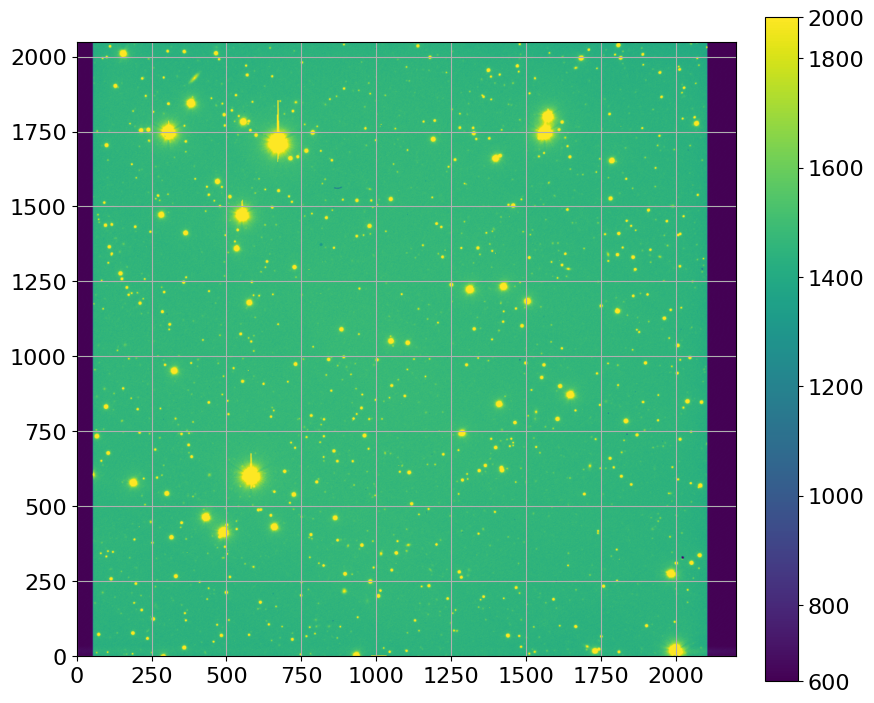

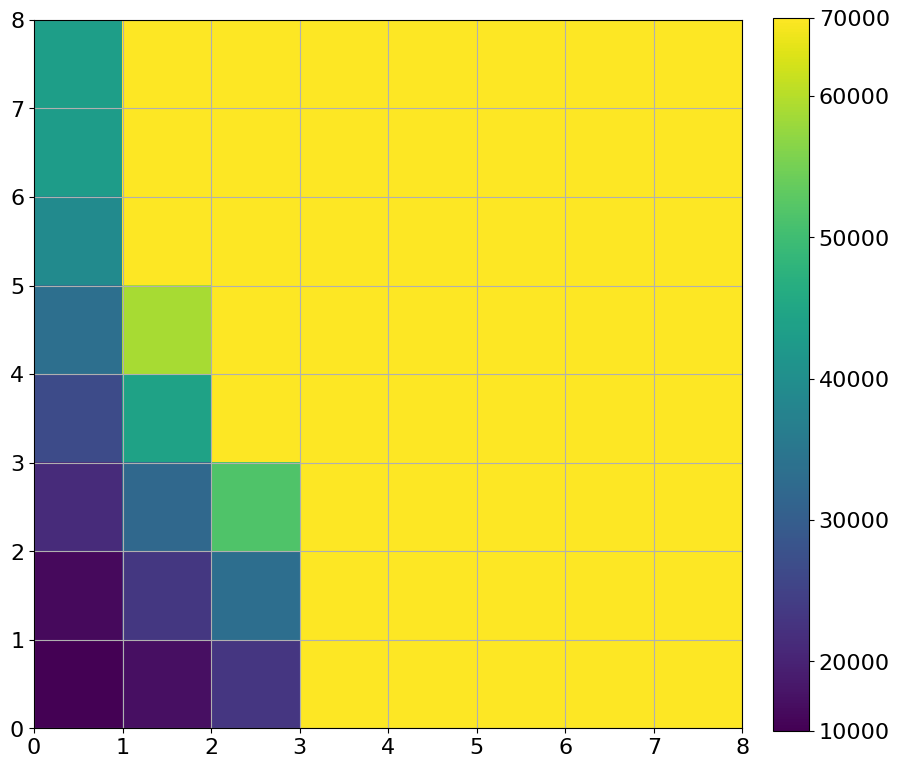

In [5]:
show_image(fits.getdata(lin_test_files[-1]))
show_image(fits.getdata(lin_test_files[-1])[1713-8:1713, 670-8:670])

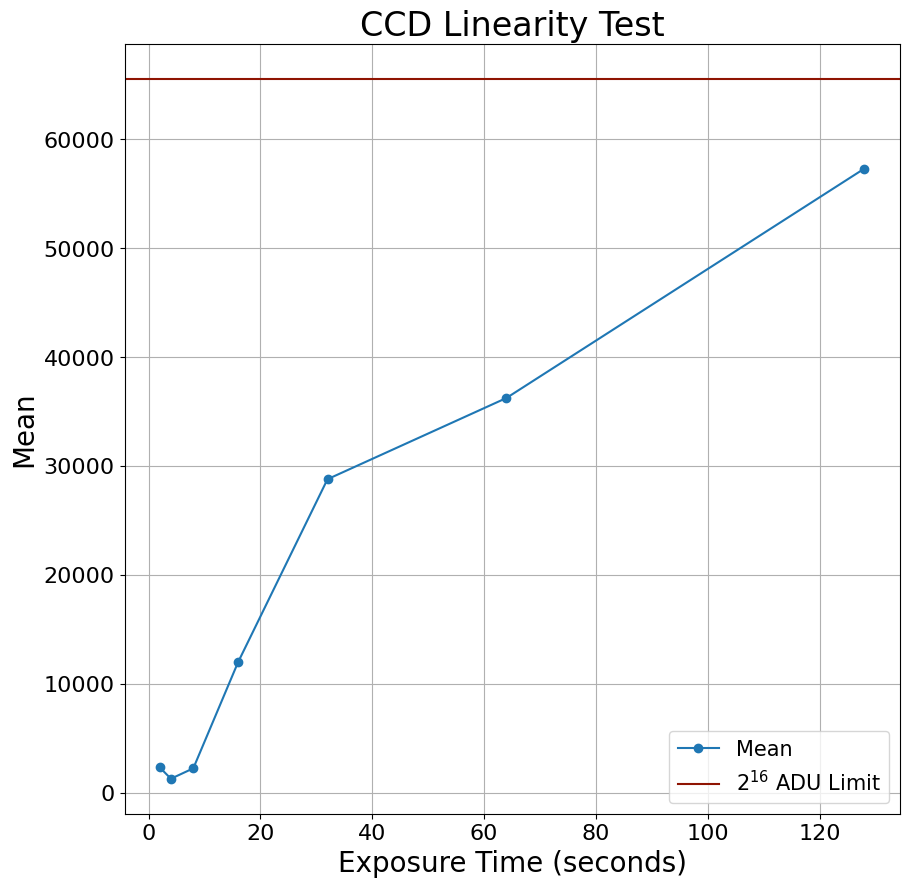

In [6]:
lin_test_data = []
for file in lin_test_files:
    lin_test_data.append(fits.getdata(file))
mean = [np.mean(data[1713-8:1713, 670-8:670]) for data in lin_test_data]
plt.plot([2**x for x in range(1, 8)], mean, "o-", label="Mean")
plt.axhline(2**16, c="xkcd:brick red", label="$2^{16}$ ADU Limit")
plt.legend(fontsize = 15)
plt.xlabel("Exposure Time (seconds)")
plt.ylabel("Mean")
plt.title("CCD Linearity Test")
plt.show()

It's... mostly linear... (in this specific cut of the image around a saturated star [it was hard to get the mean to reach near the $2^{16}$ ADU limit otherwise])

## Q2.

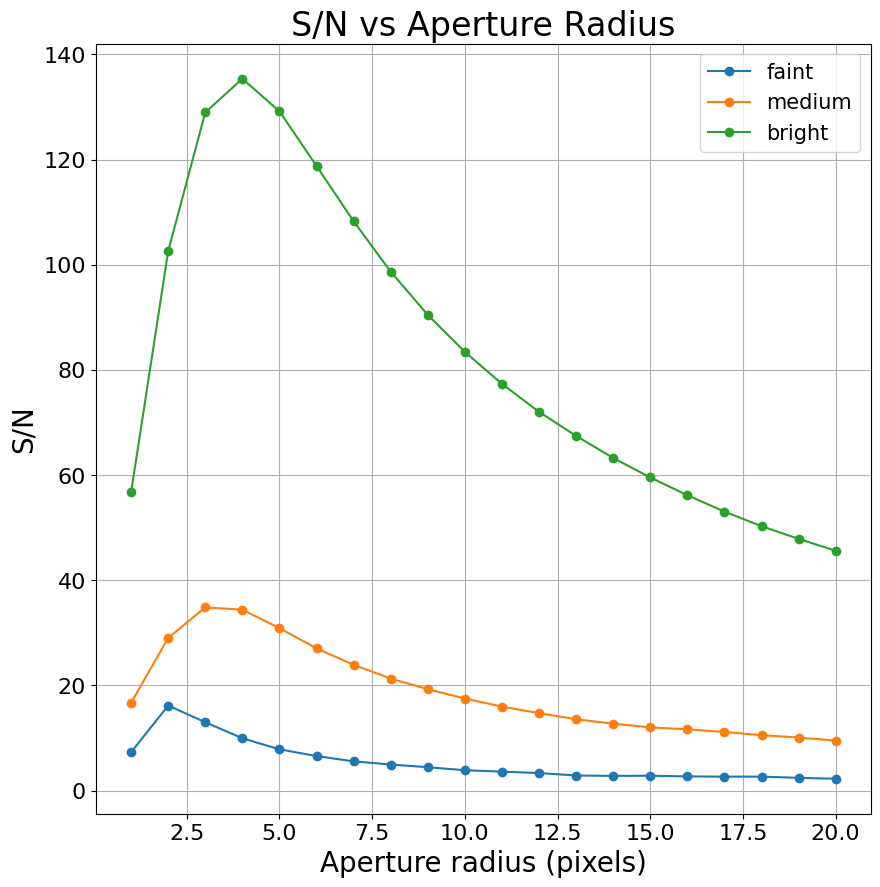

In [7]:
stars = {"faint": [490.46718, 1917.5561], "medium": [644.4979, 1671.4912], "bright": [535.84613, 418.10389]}
data = fits.getdata(reduced_dir+"a202_otzdf.fits")

radii = np.arange(1, 21)
r_in_sky = 25
r_out_sky = 30

for label, pos in stars.items():
    snr_list = []
    
    for r in radii:
        ap = CircularAperture(pos, r=r)
        ann = CircularAnnulus(pos, r_in=r_in_sky, r_out=r_out_sky)
        inner_flux = aperture_photometry(data, ap)["aperture_sum"][0]
        outer_flux = aperture_photometry(data, ann)["aperture_sum"][0]

        sigma_B = outer_flux/ann.area
        sigma_RN = 14.004669806966362 / 1.6332933482946552  # Read noise / gain from HW5

        signal = inner_flux - (ap.area * sigma_B)
        noise = np.sqrt(signal + ap.area * (sigma_B**2 + sigma_RN**2))

        snr_list.append(signal / noise)

    plt.plot(radii, snr_list, marker="o", label=label)

plt.xlabel("Aperture radius (pixels)")
plt.ylabel("S/N")
plt.title("S/N vs Aperture Radius")
plt.legend(fontsize = 15)
plt.show()

An aperture size of 3 (or 4) is best for this dataset! 4 is technically better for the bright stars but we get lower performance for dimmer stars at that point compared to 3... so I believe a good compromise in the middle is aperture of 3. But standard stars are on the brighter side so I might just use 4-5 when doing calculations with them specifically!

## Q3.

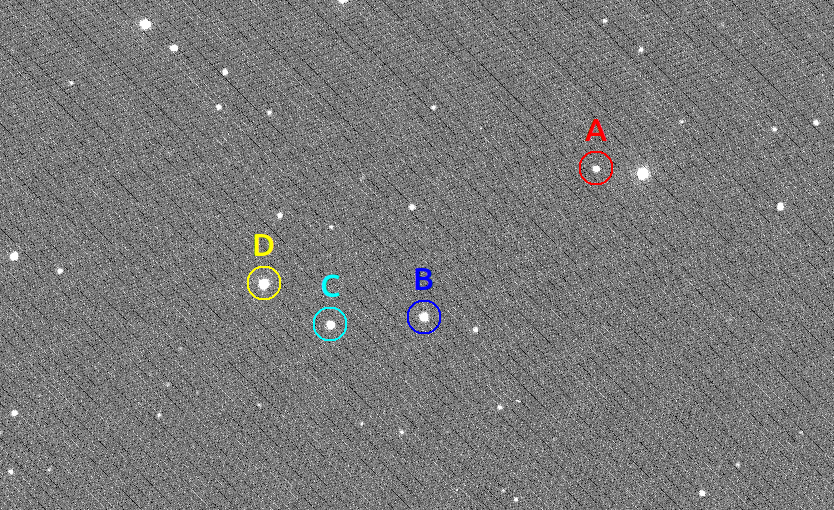
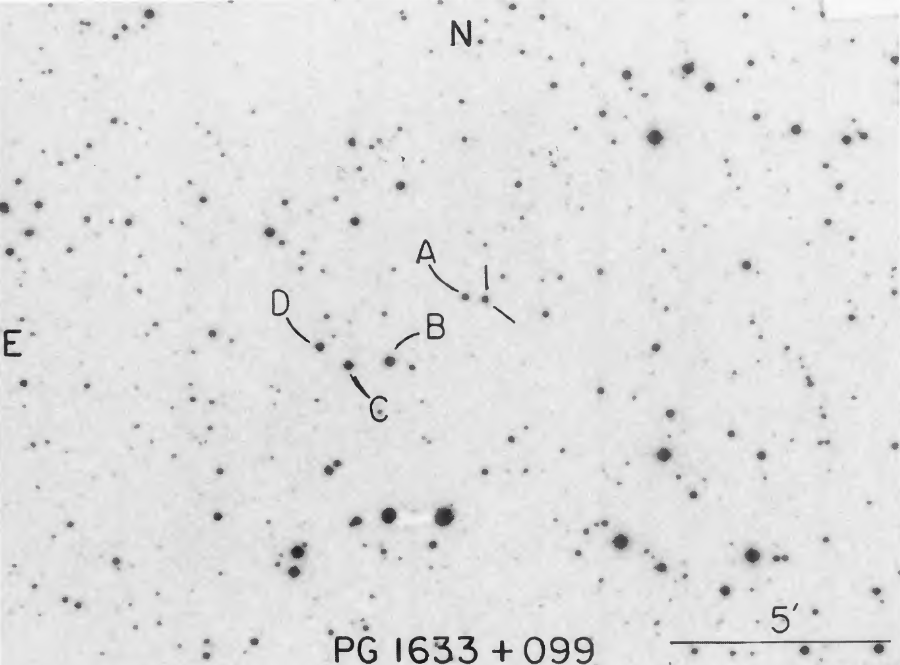

They have been identified!

In [8]:
A = [981.2381, 1031.5004]
B = [1188.323, 1209.41]
C = [1300.7504, 1218.7228]
D = [1380.1263, 1169.6151]
positions = [A, B, C, D]

## Q4.

This is all just code from `apertures.ipynb`

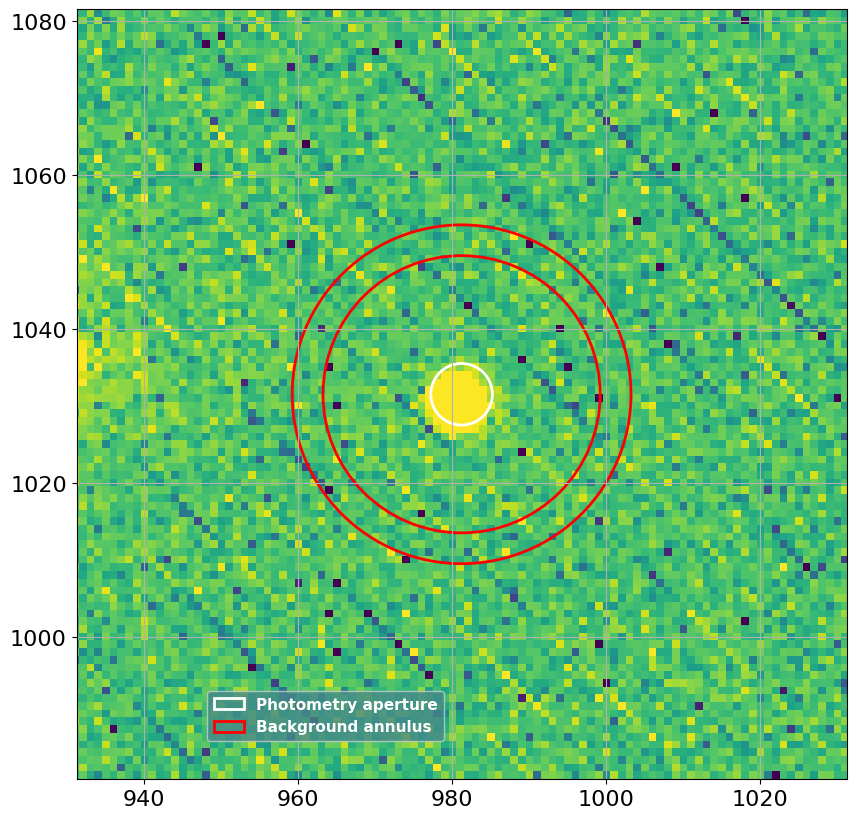

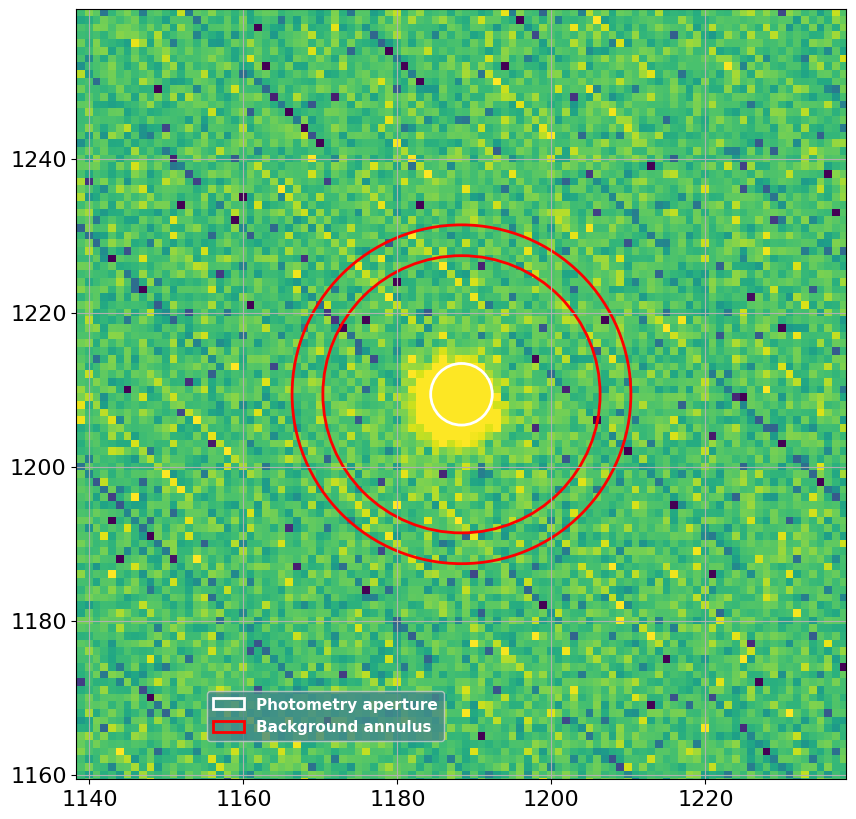

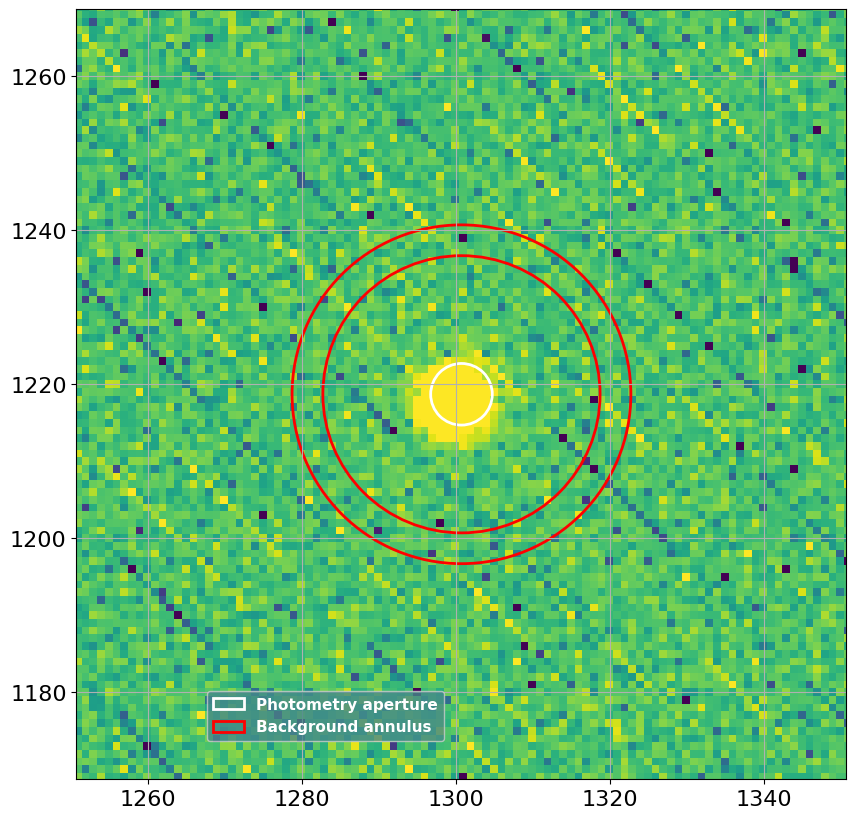

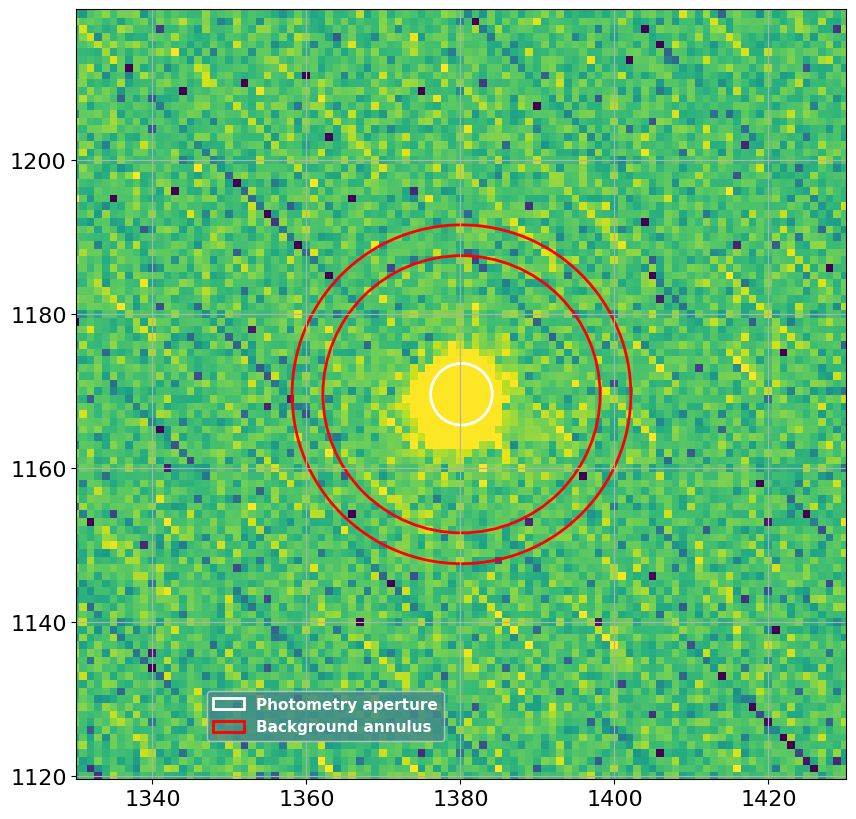

In [ ]:
aperture = CircularAperture(positions, r=4) # <- r = 4 from Q2!
annulus_aperture = CircularAnnulus(positions, r_in=18, r_out=22)

norm = simple_norm(data, 'sqrt', percent=99)
for p in positions:
    plt.imshow(data, norm=norm, interpolation='nearest')
    plt.xlim(p[0]-50, p[0]+50)
    plt.ylim(p[1]-50, p[1]+50)

    ap_patches = aperture.plot(color='white', lw=2,
                            label='Photometry aperture')
    ann_patches = annulus_aperture.plot(color='red', lw=2,
                                        label='Background annulus')
    handles = (ap_patches[0], ann_patches[0])
    plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
            handles=handles, prop={'weight': 'bold', 'size': 11})
    plt.show()

In [10]:
phot_table = aperture_photometry(data, aperture)
T = phot_table['aperture_sum']

A_circle = aperture.area
A_annulus = annulus_aperture.area
total_B = aperture_photometry(data, annulus_aperture)['aperture_sum']
B = total_B/A_annulus

m=-2.5*np.log10(T-A_circle*B)

print(f"Instrumental Magnitudes:")
for mag in m:
    print(float(mag))

Instrumental Magnitudes:
-9.838880940987895
-11.307489190466821
-10.887225476877813
-12.062650998217343


Making a function for it, as I fear it may be needed a lot more in the near future...

In [11]:
def instrumental_mags(data, positions, r=11, r_in=18, r_out=22):
    aperture = CircularAperture(positions, r=r)
    annulus_aperture = CircularAnnulus(positions, r_in=r_in, r_out=r_out)
    
    phot_table = aperture_photometry(data, aperture)
    T = phot_table['aperture_sum']
    total_B = aperture_photometry(data, annulus_aperture)['aperture_sum']
    B = total_B/annulus_aperture.area
    m=-2.5*np.log10(T-(aperture.area*B))

    return list(m)

In [12]:
instrumental_mags(data, positions)

[np.float64(-9.984403508016474),
 np.float64(-11.514190115301355),
 np.float64(-11.120306149059324),
 np.float64(-12.252278169666809)]

same numbers as the ones above!

## Q5.

In [13]:
PG1633 = {}
PG1633["U"] = [("082", 1.18), ("130", 1.23), ("131", 1.24), ("202", 1.49), ("203", 1.49), ("237", 2.15), ("238", 2.15)]
PG1633["B"] = [("083", 1.18), ("084", 1.18), ("132", 1.24), ("133", 1.24), ("204", 1.51), ("205", 1.51), ("239", 2.19), ("240", 2.19)]
PG1633["V"] = [("085", 1.18), ("086", 1.18), ("134", 1.24), ("135", 1.24), ("206", 1.52), ("207", 1.52), ("241", 2.21), ("242", 2.21)]
PG1633["R"] = [("087", 1.18), ("088", 1.18), ("136", 1.24), ("137", 1.24), ("208", 1.53), ("209", 1.53), ("243", 2.23), ("244", 2.23)]
PG1633["I"] = [("089", 1.18), ("090", 1.18), ("138", 1.24), ("139", 1.24), ("210", 1.53), ("211", 1.53), ("245", 2.26), ("246", 2.26)]
# skipping 081, 221-236 as they have a different exposure time compared to the rest in that filter (or we don't have the files)

Now is the tedious step of finding the shifts in each image... thankfully the shifts of each star is the same in each image.
So, if I find the shifts for 1 star, it will work for the rest of them. They also do not shift much as we change the filters! So it is just fine-tuning after the first round.

I'm plotting the apertures and seeing the shift along different observations and manually moving them until they properly land on the star they are aiming for. Once I got shifts from a filter, I simply switched to a different filter in the same code.

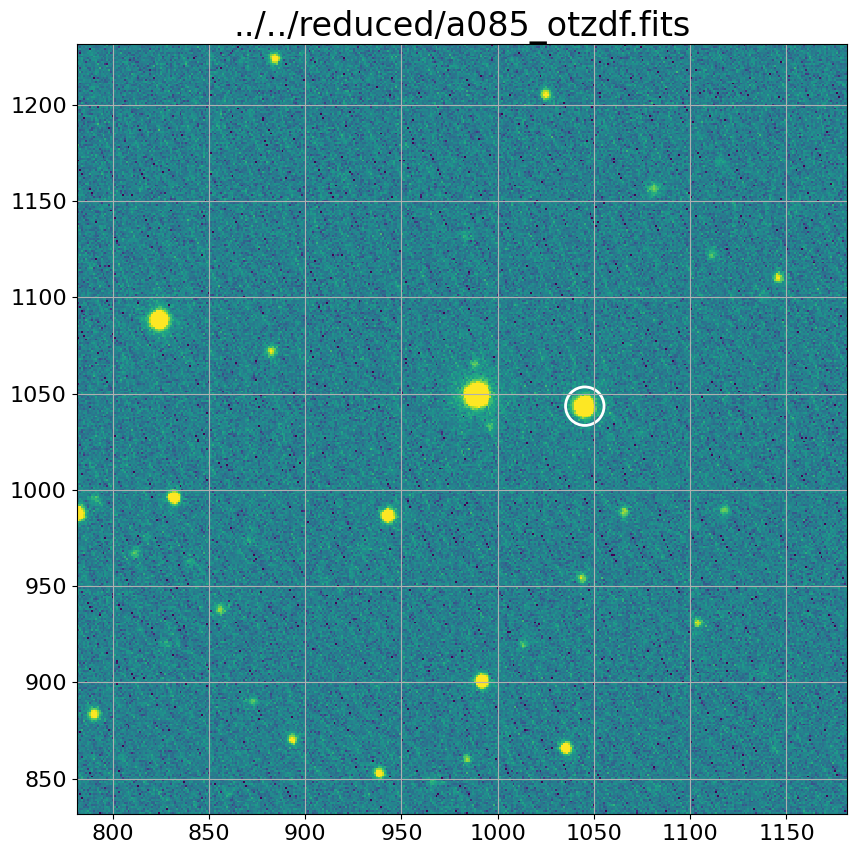

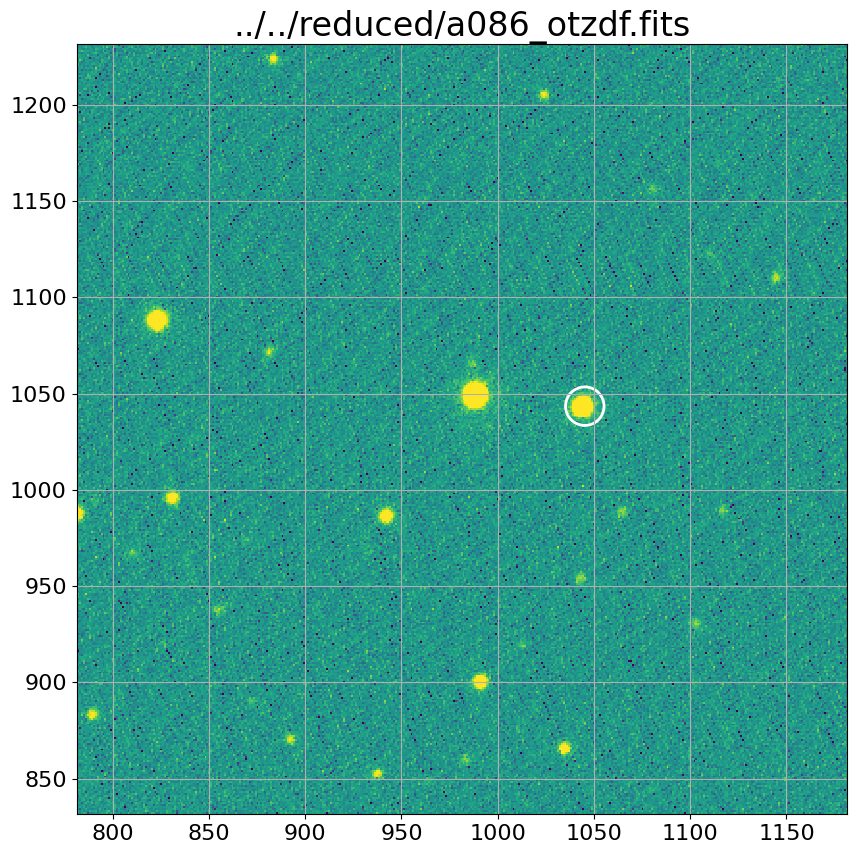

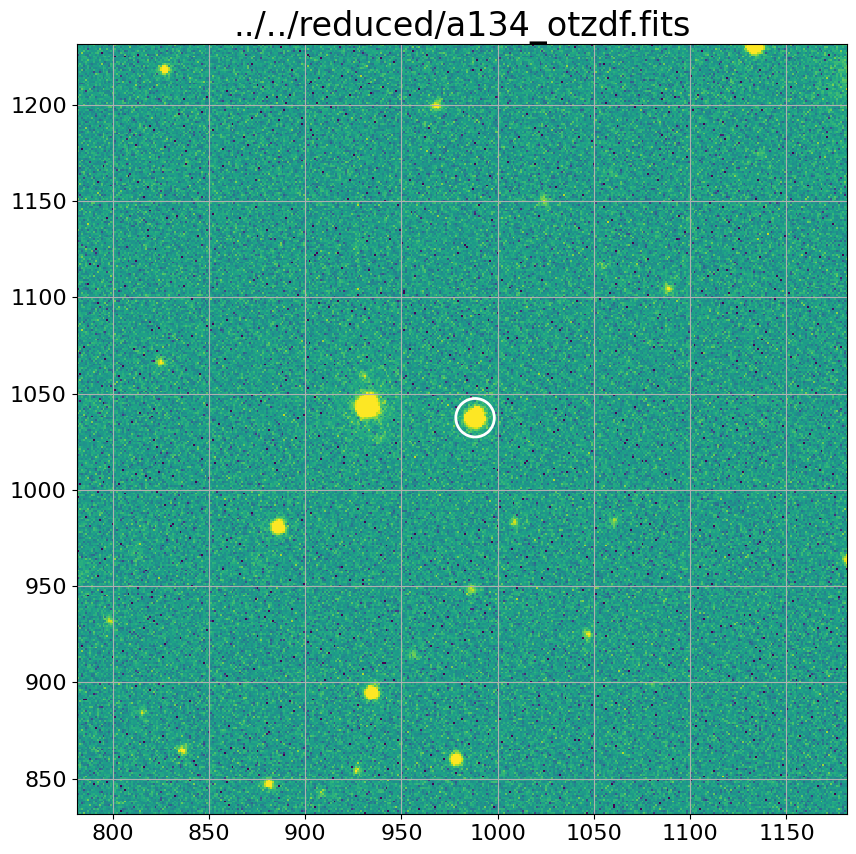

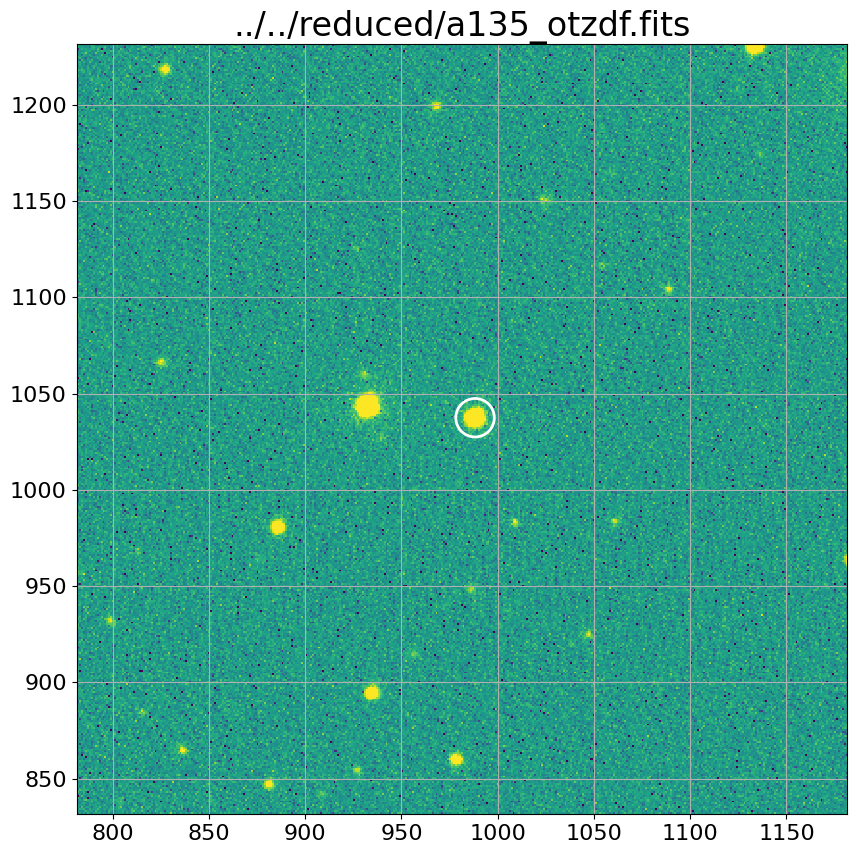

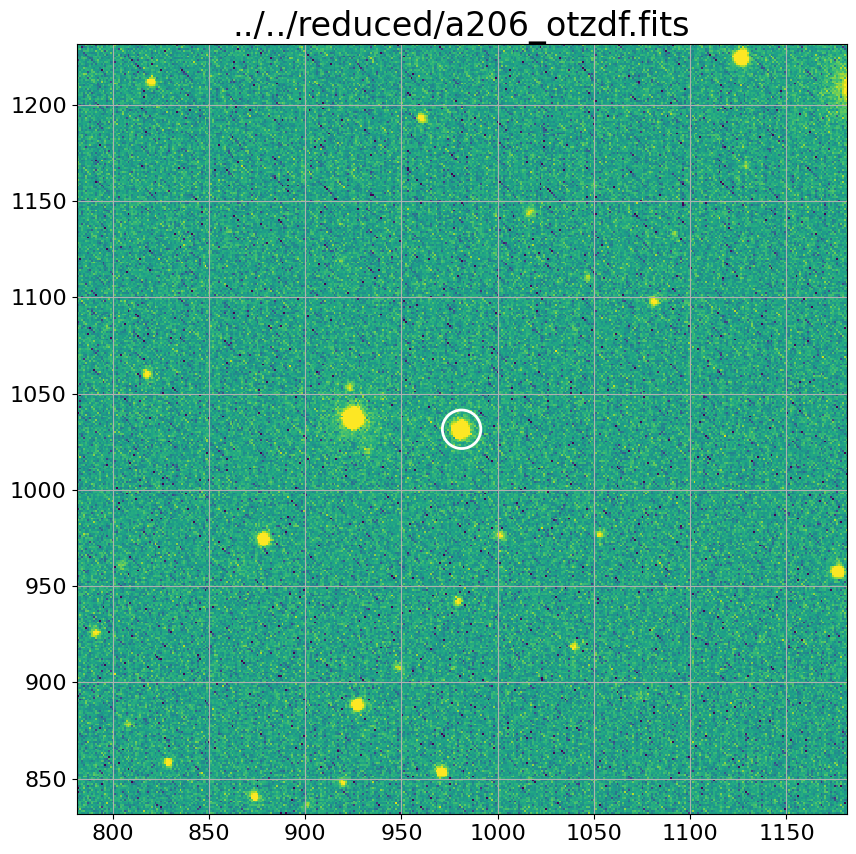

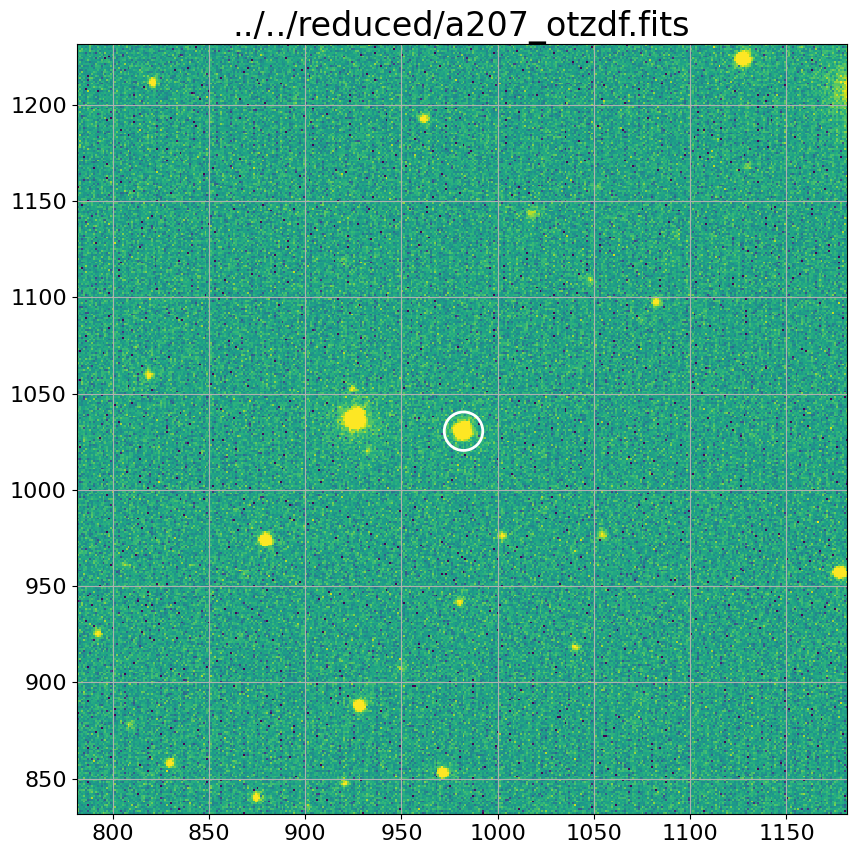

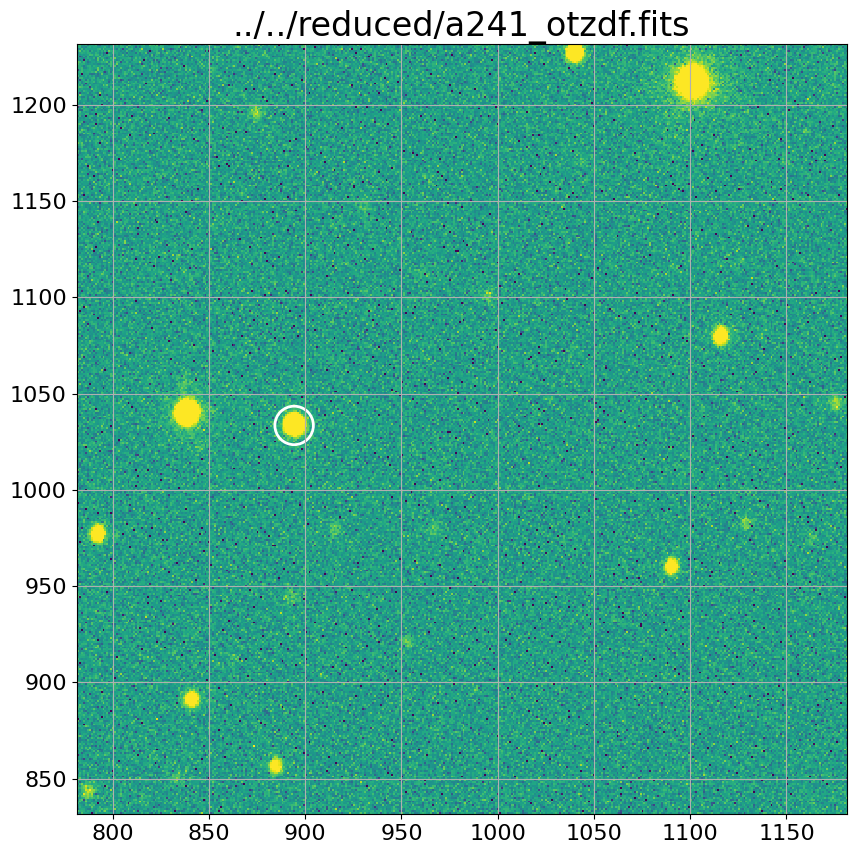

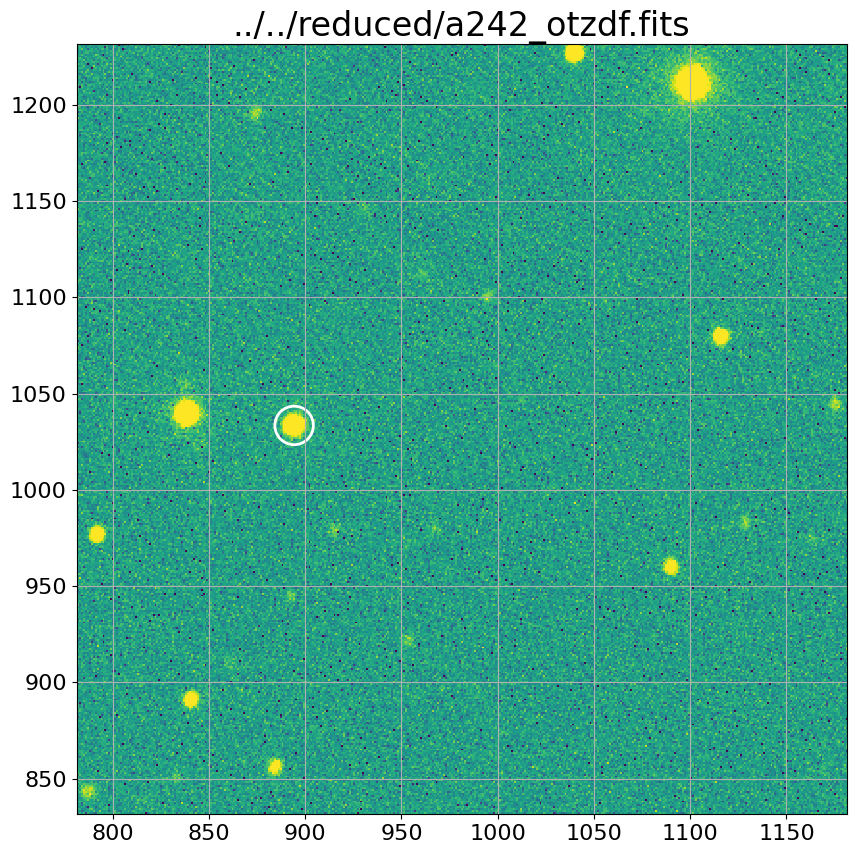

In [14]:
PG1633["U_shift"] = [(65, 12), (9, 5), (7, 5), (0, 0), (0, -2), (-88, 0), (-88, 1)]
PG1633["B_shift"] = [(65, 12), (64, 11), (8, 5), (7, 5), (0, -1), (-1, -1), (-88, 1), (-88, 2)]
PG1633["V_shift"] = [(64, 12), (64, 12), (7, 6), (7, 6), (0, 0), (1, -1), (-87, 2), (-87, 2)]
PG1633["R_shift"] = [(64, 12), (63, 12), (7, 6), (7, 6), (0, 0), (1, -1), (-87, 3), (-86, 2)]
PG1633["I_shift"] = [(61, 12), (59, 12), (6, 6), (6, 7), (-1, 1), (-1, 1), (-87, 3), (-86, 3)]

for i, observation in enumerate(PG1633["V"]):
    obs_id, airmass = observation
    file_name = reduced_dir + "a" + obs_id + "_otzdf.fits"
    data = fits.getdata(file_name)
    new_x = positions[0][0] + PG1633["V_shift"][i][0]
    new_y = positions[0][1] + PG1633["V_shift"][i][1]
    aperture = CircularAperture([new_x, new_y], r=10)

    norm = simple_norm(data, 'sqrt', percent=99)
    plt.imshow(data, norm=norm, interpolation='nearest')
    plt.xlim(positions[0][0]-200, positions[0][0]+200)
    plt.ylim(positions[0][1]-200, positions[0][1]+200)
    ap_patches = aperture.plot(color='white', lw=2,
                            label='Photometry aperture')
    handles = (ap_patches[0])
    plt.title(file_name)
    plt.show()

In [15]:
V = np.array([15.256, 12.969, 13.229, 13.691])

accepted_mags = {}
accepted_mags["A"] = [0.32+(0.873+V[0]), 0.873+V[0], V[0], V[0]-(0.505), V[0]-(1.015)]
accepted_mags["B"] = [1.007+(1.081+V[1]), 1.081+V[1], V[1], V[1]-(0.590), V[1]-(1.090)]
accepted_mags["C"] = [1.138+(1.134+V[2]), 1.134+V[2], V[2], V[2]-(0.618), V[2]-(1.138)]
accepted_mags["D"] = [-0.025+(0.535+V[3]), 0.535+V[3], V[3], V[3]-(0.324), V[3]-(0.650)]

Beyond this point my sort-of clean function-based coding falls apart. Traverse at your own risk.

slope for U = -0.548
intercept for U = 27.094


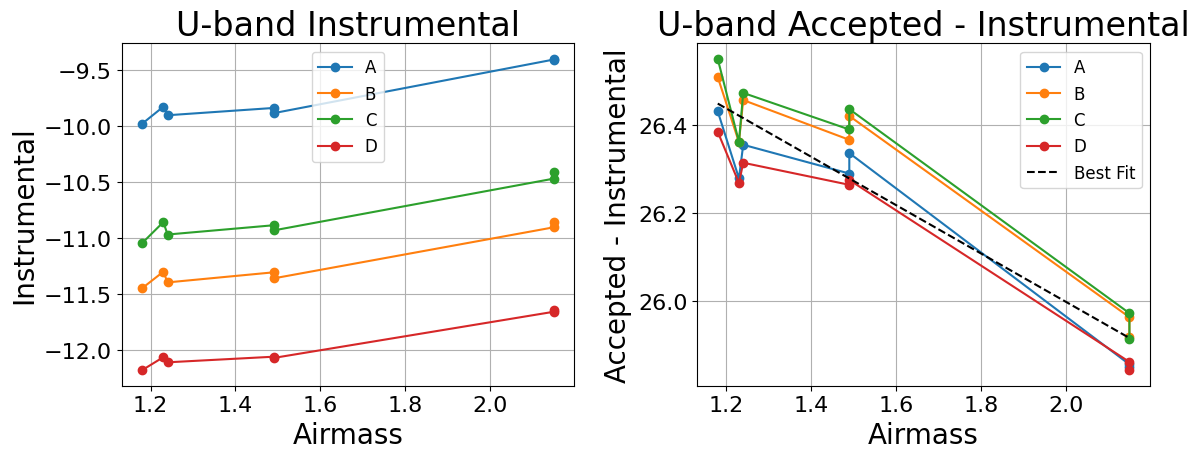

slope for B = -0.277
intercept for B = 28.552


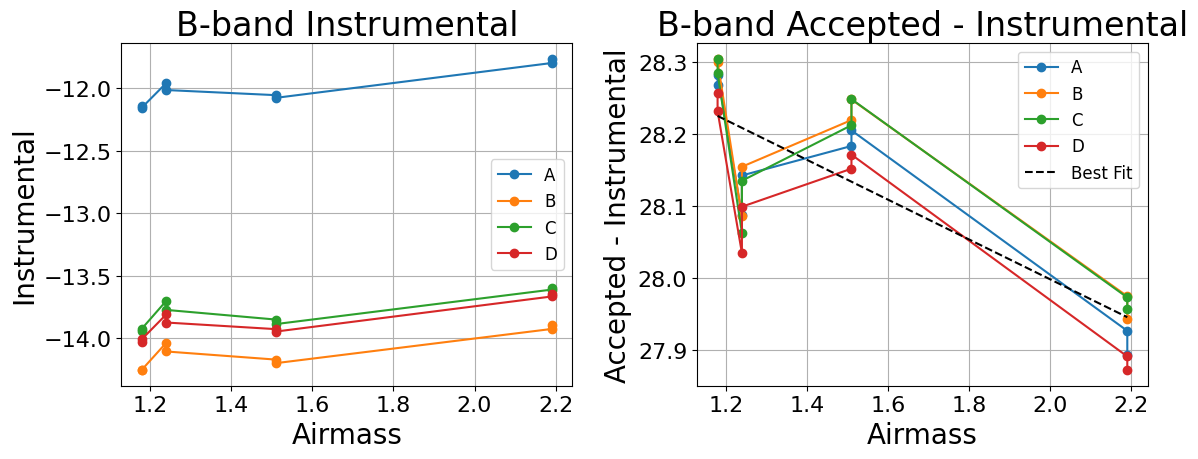

slope for V = -0.441
intercept for V = 27.806


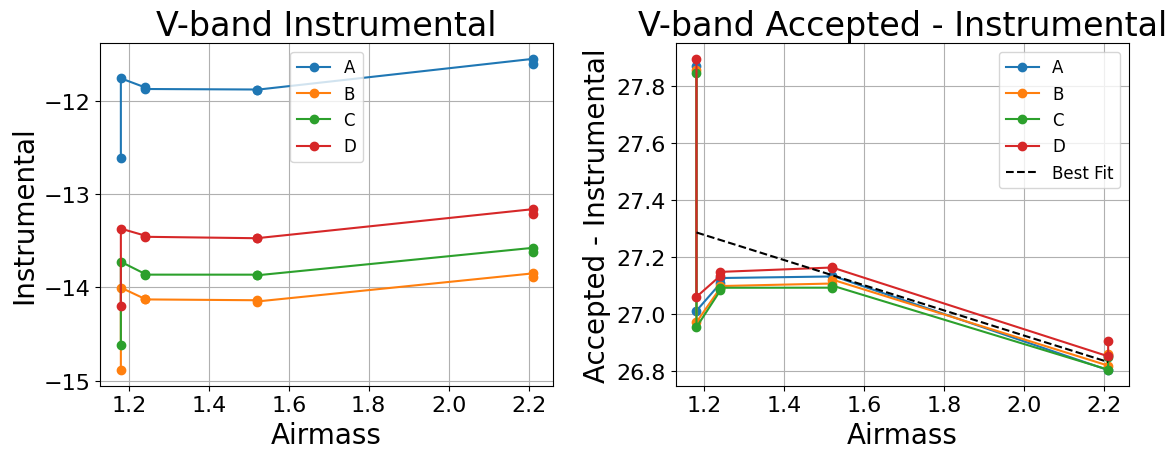

slope for R = -0.369
intercept for R = 27.603


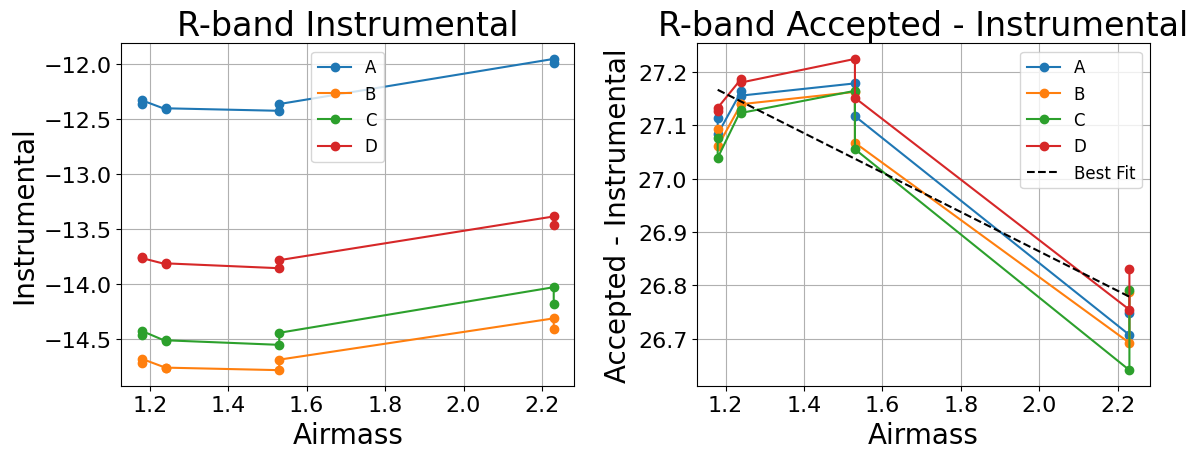

slope for I = -0.341
intercept for I = 27.106


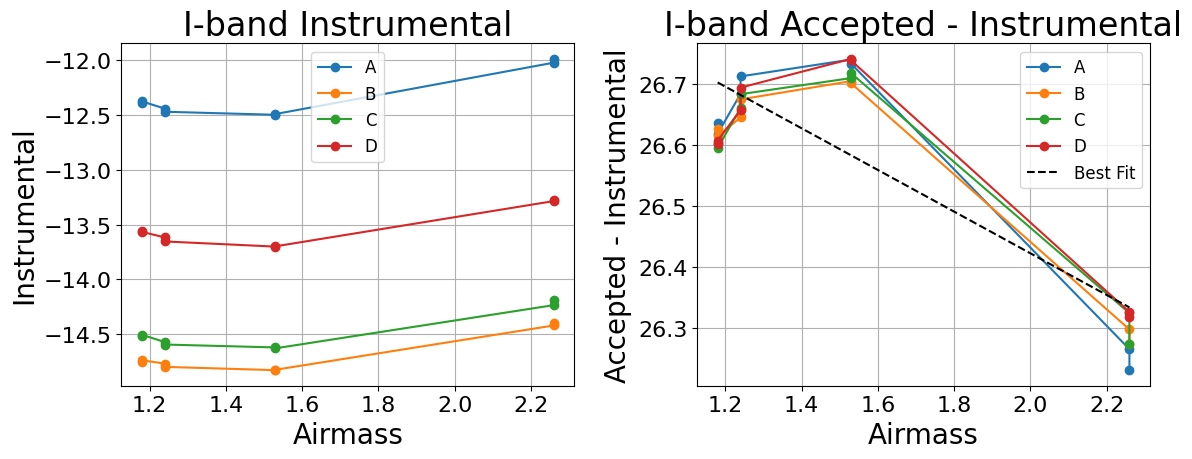

In [ ]:
slope = {}
intercept = {}
m_subtracted = {}
airmasses = {}
for j, filter in enumerate(["U", "B", "V", "R", "I"]):
    airmass_list = []
    mag_list = []
    for i, observation in enumerate(PG1633[filter]):
        airmass_list.append(observation[1])
        file_name = reduced_dir + "a" + observation[0] + "_otzdf.fits"
        data = fits.getdata(file_name)
        shift = np.array(PG1633[filter+"_shift"][i])
        new_positions = positions + shift
        mag_list.append(instrumental_mags(data, new_positions, r=4, r_in=20, r_out=30))

    labels = ["A", "B", "C", "D"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    for i in range(4):
        ax1.plot(airmass_list, np.array(mag_list)[:, i], "o-", label=labels[i])
    ax1.legend(fontsize=12)
    ax1.set_title(f"{filter}-band Instrumental")
    ax1.set_xlabel("Airmass")
    ax1.set_ylabel("Instrumental")

    # my dictionary ways have backfired on me
    # I don't know what's happening anymore
    # the gods have cursed me for my hubris and my work never finishes

    fitting_x = []
    fitting_y = []
    for i in range(4):
        acc_sub_ins = accepted_mags[labels[i]][j] - np.array(mag_list)[:, i]
        ax2.plot(airmass_list, acc_sub_ins, "o-", label=labels[i])
        for x, y in zip(airmass_list, acc_sub_ins):
            fitting_x.append(x)
            fitting_y.append(y)

    airmasses[filter] = np.array(fitting_x)
    m_subtracted[filter] = np.array(fitting_y)
    m, b = np.polyfit(fitting_x, fitting_y, 1)
    slope[filter] = m
    intercept[filter] = b
    print(f"slope for {filter} = {m:.3f}")
    print(f"intercept for {filter} = {b:.3f}")

    x_fit = np.linspace(min(fitting_x), max(fitting_x), 100)
    ax2.plot(x_fit, m*x_fit + b, "k--", label="Best Fit")
    ax2.legend()

    ax2.legend(fontsize=12)
    ax2.set_title(f"{filter}-band Accepted - Instrumental")
    ax2.set_xlabel("Airmass")
    ax2.set_ylabel("Accepted - Instrumental")

    plt.tight_layout()
    plt.show()

## Q6.

U band, VR: -0.03996343719954733 25.40371005166714
U band, BV: -0.02100230336726758 25.402381507548167


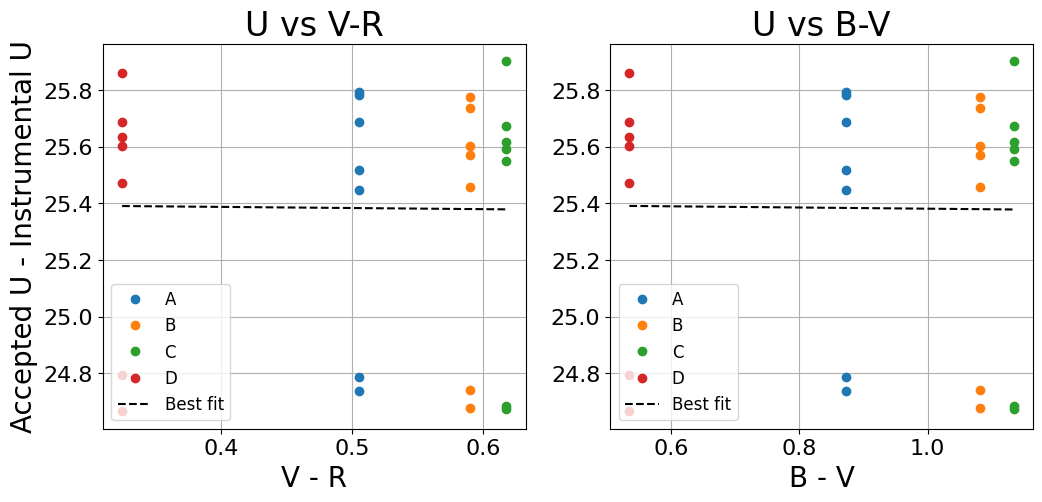

B band, VR: 0.4308002052484738 27.485007546563377
B band, BV: 0.18967972773278607 27.532590137692193


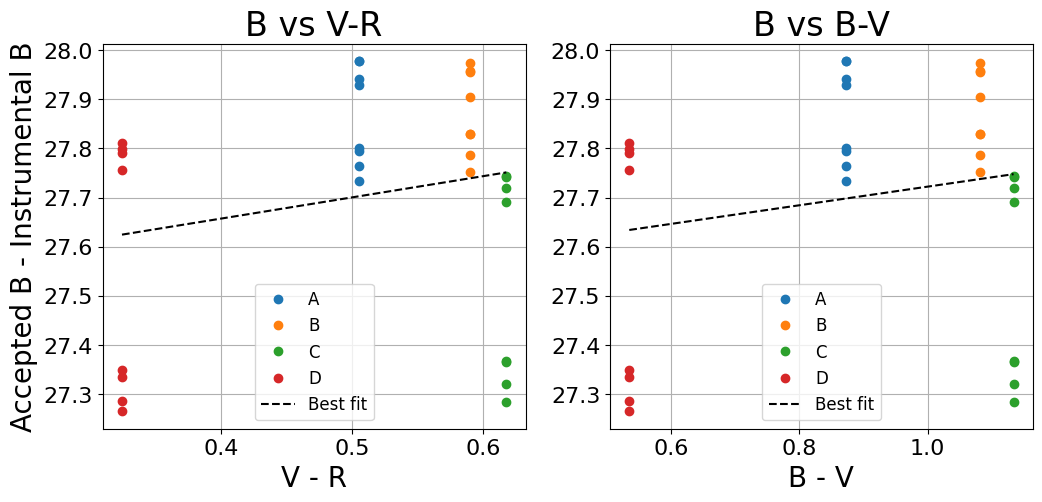

V band, VR: 0.2503088035231497 26.321720050356912
V band, BV: 0.05922131989196253 26.395550098058937


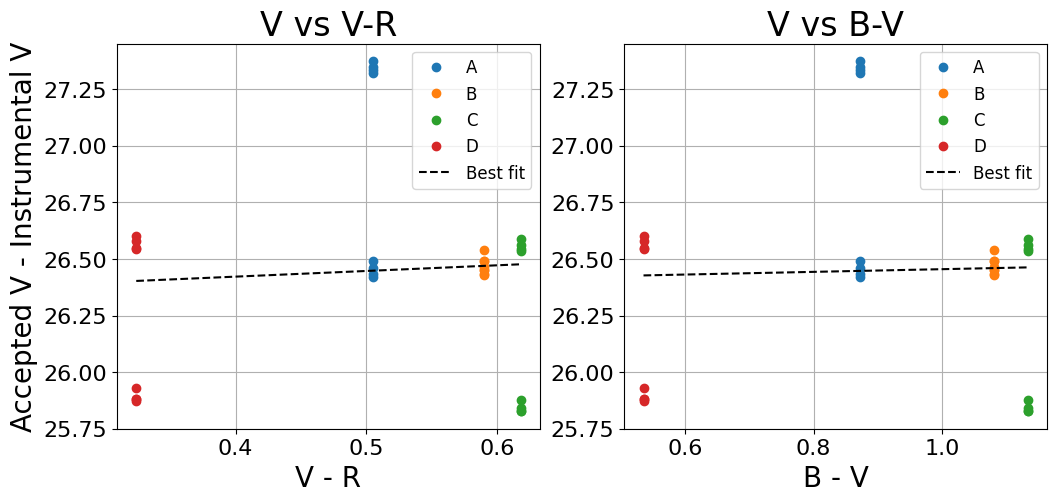

R band, VR: 0.2841968189188828 26.316369362030866
R band, BV: 0.11500186656062136 26.35693365142803


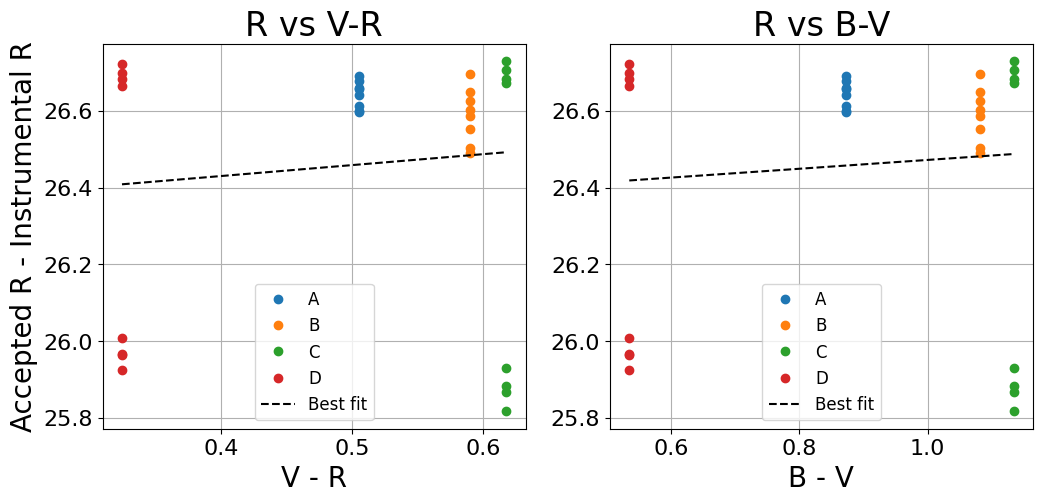

I band, VR: 0.46158276265767006 25.810701082243387
I band, BV: 0.20410742671997975 25.860891802375185


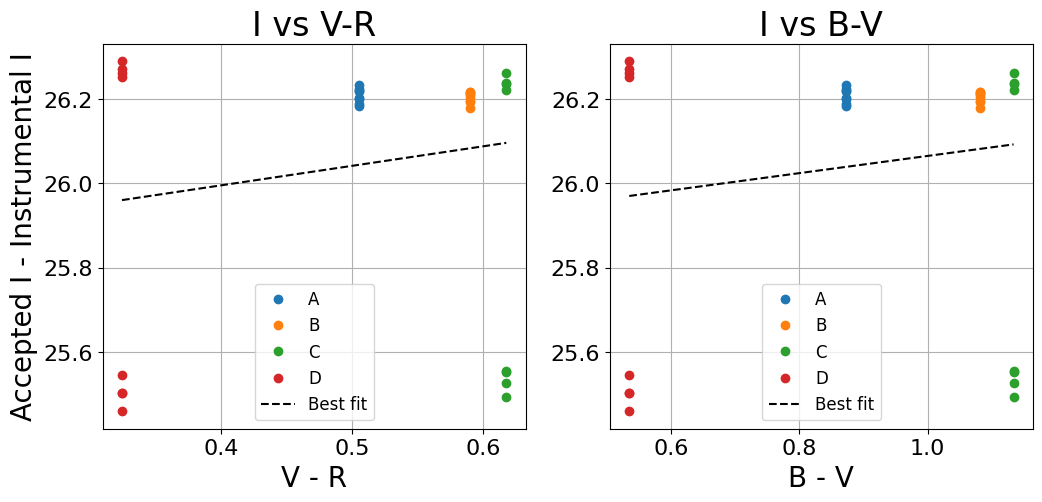

In [ ]:
m_corrected = {}
labels = ["A", "B", "C", "D"]
VR = {star: accepted_mags[star][2] - accepted_mags[star][3] for star in labels}
BV = {star: accepted_mags[star][1] - accepted_mags[star][2] for star in labels}

for i, filter in enumerate(["U", "B", "V", "R", "I"]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    m_corrected[filter] = m_subtracted[filter] + slope[filter] * airmasses[filter]
    acc_mag = {star: accepted_mags[star][i] for star in labels}

    fitting_x_vr, fitting_x_bv, fitting_y = [], [], [] # I know this is bad coding, but it will take too long to untangle this tonight (it works tho)

    for j, star in enumerate(labels):
        y_vals = m_corrected[filter][j::4]
        
        x_vr = np.ones(len(y_vals))*VR[star]
        ax1.plot(x_vr, y_vals, "o", label=star)

        x_bv = np.ones(len(y_vals))*BV[star]
        ax2.plot(x_bv, y_vals, "o", label=star)

        fitting_x_vr.extend(x_vr)
        fitting_x_bv.extend(x_bv)
        fitting_y.extend(y_vals)

    fitting_x_vr = np.array(fitting_x_vr)
    fitting_x_bv = np.array(fitting_x_bv)
    fitting_y = np.array(fitting_y)

    m_vr, b_vr = np.polyfit(fitting_x_vr, fitting_y, 1)
    print(filter, "band, VR:", m_vr, b_vr)
    m_bv, b_bv = np.polyfit(fitting_x_bv, fitting_y, 1)
    print(filter, "band, BV:", m_bv, b_bv)

    xfit_vr = np.linspace(fitting_x_vr.min(), fitting_x_vr.max(), 100)
    xfit_bv = np.linspace(fitting_x_bv.min(), fitting_x_bv.max(), 100)

    ax1.plot(xfit_vr, m_vr * xfit_vr + b_vr, "k--", label="Best fit")
    ax2.plot(xfit_bv, m_bv * xfit_bv + b_bv, "k--", label="Best fit")

    ax1.set_xlabel("V - R")
    ax1.set_ylabel(f"Accepted {filter} - Instrumental {filter}")
    ax1.set_title(f"{filter} vs V-R")
    ax1.legend(fontsize=12)

    ax2.set_xlabel("B - V")
    ax2.set_title(f"{filter} vs B-V")
    ax2.legend(fontsize=12)
    plt.show()

### (V-R) Color
| Band | Zero point (ZP) | First-order color term |
|------|------------------|------------------------|
| U    | 25.4037          | -0.0399                 |
| B    | 27.4850          | 0.4308                 |
| V    | 26.3217          | 0.2503                |
| R    | 26.3164          | 0.2842                |
| I    | 25.8107          | 0.4616                |

### (B-V) Color
| Band | Zero point (ZP) | First-order color term |
|------|------------------|------------------------|
| U    | 25.4024          | -0.0210                 |
| B    | 27.5326          | 0.1897                 |
| V    | 26.3955          | 0.0592                |
| R    | 26.3569          | 0.1150                |
| I    | 25.8609          | 0.2041                |

## Q7.

Big thank you to Brayan for showing me how he did starfinder in class <3

In [18]:
NGC_V = glob.glob(reduced_dir+"a159_otzdf.fits")[0]
NGC_B = glob.glob(reduced_dir+"a160_otzdf.fits")[0]

V_data = fits.getdata(NGC_V)
B_data = fits.getdata(NGC_B)

_, median, std = sigma_clipped_stats(V_data, sigma=3)
daofind = DAOStarFinder(fwhm=3, threshold=5*std)
sources_V = daofind(V_data - median)

_, median, std = sigma_clipped_stats(B_data, sigma=3)
daofind = DAOStarFinder(fwhm=3, threshold=5*std)
sources_B = daofind(B_data - median)

In [19]:
pos_B = np.transpose((sources_B['xcentroid'], sources_B['ycentroid']))
pos_V = np.transpose((sources_V['xcentroid'], sources_V['ycentroid']))

matches = []
max_dist = 3.0

for i, (xB, yB) in enumerate(pos_B):
    best_j = None
    best_dist = np.inf

    for j, (xV, yV) in enumerate(pos_V):
        dist = np.sqrt((xB - xV)**2 + (yB - yV)**2)
        if dist < best_dist:
            best_dist = dist
            best_j = j

    if best_dist < max_dist:
        matches.append((i, best_j, best_dist))

pos_B_match = np.array([pos_B[i] for i, _, _ in matches])
pos_V_match = np.array([pos_V[j] for _, j, _ in matches])

In [20]:
B_mags = np.array(instrumental_mags(B_data, pos_B_match))
V_mags = np.array(instrumental_mags(V_data, pos_V_match))

ZP_B = 27.5326
ZP_V = 26.3955
A_B = -0.277
A_V = -0.441
C_B = 0.1897
C_V = 0.0592
X_B = 1.09
X_V = 1.09

colour = ((B_mags - V_mags) + (ZP_B - ZP_V) + (A_B*X_B - A_V*X_V))/(1 - C_B - C_V)
B_calibrated = B_mags + ZP_B + A_B*X_B + C_B*colour
V_calibrated = V_mags + ZP_V + A_V*X_V + C_V*colour

/tmp/ipykernel_133918/3666692862.py:9: RuntimeWarning: invalid value encountered in log10
  m=-2.5*np.log10(T-(aperture.area*B))
/tmp/ipykernel_133918/3666692862.py:9: RuntimeWarning: invalid value encountered in log10
  m=-2.5*np.log10(T-(aperture.area*B))


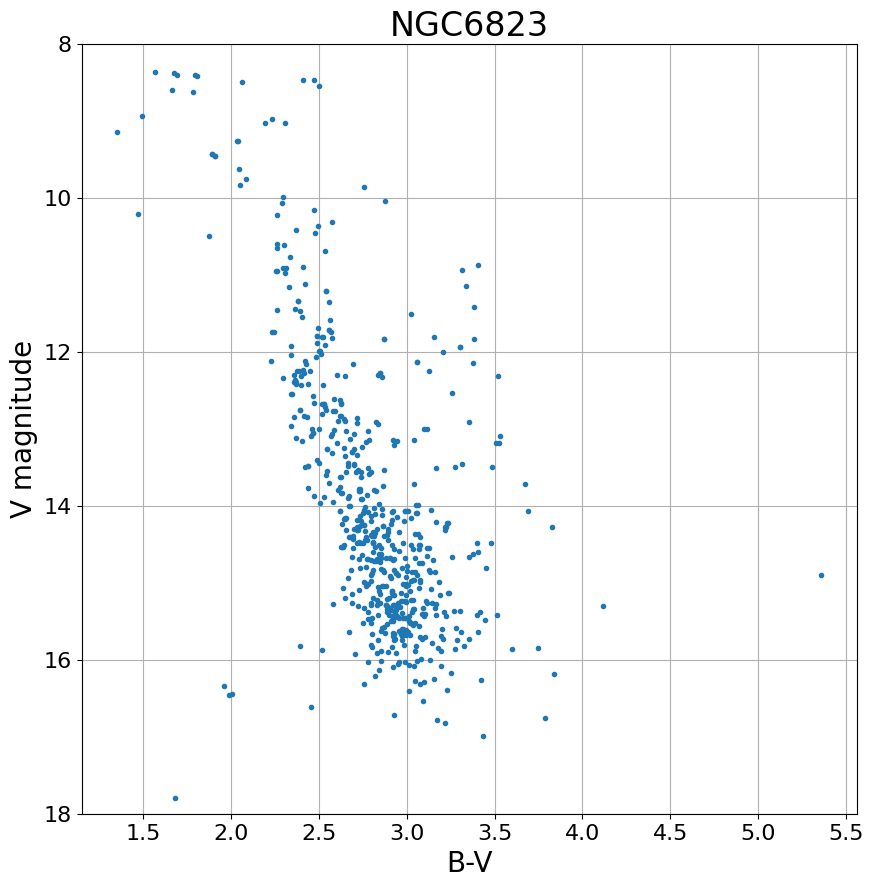

In [21]:
plt.plot(B_calibrated-V_calibrated, V_calibrated, ".")
plt.ylim(18, 8)
plt.ylabel("V magnitude")
plt.xlabel("B-V")
plt.title("NGC6823")
plt.show()

!!!! wow look at that so cool !!!!

Thank you for the fun class!